# Reproducing the MorphAgent Tau figures

MorphAgent designs image features for a biological question, rather than
reusing a fixed descriptor panel. This notebook asks what those features buy
you on Tau, and reproduces the published panels end to end:

| Section | Panel | What it establishes about MorphAgent features |
|---|---|---|
| 2 | Tau feature space | they span a far richer phenotypic space than an expert panel, while preserving its structure |
| 3 | WT versus P301S+S320F | they separate genotypes better in both imaging modalities, most of all at super-resolution |
| 4 | Six-class genotype | they resolve six Tau genotypes at higher accuracy and lower false-positive rate |
| 5 | Gene expression prediction | they carry transcriptomic information that Tau abundance alone does not |
| 6 | Top-level heatmap | morphology-defined biological processes and GO programs converge on the same genes |
| 7 | Middle-level heatmap | those correspondences resolve into subcellular architecture × GRN modules |

Everything needed is inside this folder — no downloads, no credentials, no
external checkouts. Each section recomputes its figure from
`data/tables/` or `source/heatmap/` and then prints the recomputed number
next to the published one, so the agreement is visible rather than asserted.

**Runtime.** Sections 1–4 and 6–7 take well under a minute in total. Section 5
scores the full transcriptome and takes about seven minutes on 24 workers;
it has a switch for a fast pass.


---
## 1. Setup, data and the two feature lists

Install the dependencies once, from the tutorial root:

```bash
pip install -r requirements.txt
```

In [64]:
import sys
from pathlib import Path

def tutorial_root() -> Path:
    candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    try:
        candidates = [Path(__vsc_ipynb_file__).resolve().parent, *candidates]
    except NameError:
        pass
    for p in candidates:
        if (p / "code" / "paths.py").is_file():
            return p
        if p.name == "notebook" and (p.parent / "code" / "paths.py").is_file():
            return p.parent
    raise FileNotFoundError("Cannot find the tutorial root (the folder that contains code/paths.py).")

ROOT = tutorial_root()
sys.path.insert(0, str(ROOT / "code"))
print("Tutorial root:", ROOT)


Tutorial root: tutorial_Tau


In [65]:
import importlib

missing = []
for module, package in {
    "numpy": "numpy", "pandas": "pandas", "scipy": "scipy",
    "sklearn": "scikit-learn", "matplotlib": "matplotlib", "joblib": "joblib",
}.items():
    try:
        mod = importlib.import_module(module)
        print(f"  {package:<14} {getattr(mod, '__version__', 'unknown')}")
    except ImportError:
        missing.append(package)

if missing:
    raise SystemExit("Missing packages: pip install " + " ".join(missing))
print("\nEnvironment ready.")

  numpy          2.2.6
  pandas         2.3.3
  scipy          1.15.3
  scikit-learn   1.7.2
  matplotlib     3.10.7
  joblib         1.5.3

Environment ready.


In [ ]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
import importlib

def tutorial_root() -> Path:
    candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    try:
        candidates = [Path(__vsc_ipynb_file__).resolve().parent, *candidates]
    except NameError:
        pass
    for p in candidates:
        if (p / "code" / "paths.py").is_file():
            return p
        if p.name == "notebook" and (p.parent / "code" / "paths.py").is_file():
            return p.parent
    raise FileNotFoundError("Cannot find the tutorial root (the folder that contains code/paths.py).")

ROOT = tutorial_root()
code_dir = str(ROOT / "code")
if code_dir not in sys.path:
    sys.path.insert(0, code_dir)

import paths
import tau_pca
import tau_classification as tc
import tau_prediction as tp
import tau_heatmap as th
importlib.reload(paths)
importlib.reload(tau_pca)
importlib.reload(tc)
importlib.reload(tp)
importlib.reload(th)

%matplotlib inline
pd.set_option("display.width", 220)

# Collects every reproduced-versus-published comparison for the closing table.
checks = {}
print("Imported analysis modules from", code_dir)


### 1.1 What ships with the tutorial

```
tutorial_Tau/
  notebook/                    this notebook
  code/                        the analysis modules it calls
  source/
    feature_lists/             the two MorphAgent feature lists
    splits/                    ten fixed train/validation/test resamples
    cached_results/            the values reported in the manuscript
    heatmap/                   morphology classes, GO terms, architectures, GRNs
  data/
    tables/                    the measurement tables (all bundled)
    outputs/                   figures and CSVs written by this notebook
```

`data/tables/` holds already-measured features rather than raw microscopy,
which is what keeps the tutorial self-contained and quick to run.


In [68]:
rows = []
for label, path in [
    ("§2  MorphAgent 301 features (WT cohort)", paths.WT_MORPHAGENT),
    ("§2  expert 16 features (WT cohort)", paths.WT_EXPERT),
    ("§2  mean cellular Tau intensity", paths.WT_TAU_INTENSITY),
    ("§3–4  MorphAgent features (mutant cohort)", paths.MUTANT_MORPHAGENT),
    ("§3–4  expert features (mutant cohort)", paths.MUTANT_EXPERT),
    ("§5  MorphAgent 400 features", paths.PRED_MORPHAGENT),
    ("§5  expert features", paths.PRED_EXPERT),
    ("§5  transcriptome", paths.PRED_TRANSCRIPTOME),
        ("§6–7  morphology classes", paths.HEATMAP_MORPHOLOGY_CLASSES),
        ("§6–7  GO terms", paths.HEATMAP_GO_TERMS),
        ("§7  subcellular architectures", paths.HEATMAP_ARCHITECTURES),
        ("§7  feature–gene map", paths.HEATMAP_FEATURE_GENES),
        ("§7  GRN modules", paths.HEATMAP_GRN_MODULES),
]:
    head = pd.read_csv(path, nrows=1)
    rows.append({
        "table": label,
        "file": path.name,
        "MB": round(path.stat().st_size / 1e6, 2),
        "columns": head.shape[1],
        "rows": sum(1 for _ in open(path, encoding="utf-8")) - 1,
    })

inventory = pd.DataFrame(rows)
print(inventory.to_string(index=False))
print(f"\nTotal bundled: {inventory.MB.sum():.1f} MB")


                                    table                                file   MB  columns  rows
  §2  MorphAgent 301 features (WT cohort)      wt_morphagent_301_features.csv 0.28      302    58
       §2  expert 16 features (WT cohort)           wt_expert_16_features.csv 0.01       17    58
          §2  mean cellular Tau intensity      wt_mean_cell_tau_intensity.csv 0.00        2    58
§3–4  MorphAgent features (mutant cohort)      mutant_morphagent_features.csv 5.79      351   993
    §3–4  expert features (mutant cohort)          mutant_expert_features.csv 0.22       15   993
              §5  MorphAgent 400 features predict_morphagent_400_features.csv 0.26      401    58
                      §5  expert features         predict_expert_features.csv 0.01       17    58
                        §5  transcriptome           predict_transcriptome.csv 7.92    19811    58

Total bundled: 14.5 MB


### 1.2 The two feature lists

Two MorphAgent feature sets appear in this tutorial, both shipped as plain
CSVs under `source/feature_lists/`:

* **301 features** — the Tau descriptor space behind the classification
  figure. These are code-derived measurements, retained after review of a
  larger candidate set with semantically overlapping descriptors collapsed
  to one representative each.
* **400 features** — the descriptor space used for transcriptome
  prediction: 200 code-derived measurements (`code_` prefix) plus 200
  vision-language descriptors (`vlm_` prefix).

The two lists were designed on different cohorts and are independent of one
another. The tutorial ships the feature names and their measured values; the
descriptor generation prompts are not included.

In [69]:
list_301 = pd.read_csv(paths.LIST_301)
list_400 = pd.read_csv(paths.LIST_400)

print(f"301-feature list: {len(list_301)} features, all {list_301.feature_kind.unique()[0]}-derived")
print("review score distribution:")
print(list_301.review_score.value_counts().sort_index().to_string())

print(f"\n400-feature list: {len(list_400)} features")
print(list_400.feature_kind.value_counts().to_string())

301-feature list: 301 features, all code-derived
review score distribution:
review_score
2      6
3      4
4     14
5    277

400-feature list: 400 features
feature_kind
code    200
vlm     200


In [70]:
print("301-feature list — first 10 entries")
print(list_301.head(10).to_string(index=False))

print("\n400-feature list — code-derived and vision-language examples")
print(list_400.groupby("feature_kind").head(4).to_string(index=False))

301-feature list — first 10 entries
 rank                                 feature_name feature_kind  review_score
    1             tau_filament_fragmentation_score         code             5
    2              tau_filament_texture_anisotropy         code             5
    3             tau_soma_granularity_scale_ratio         code             5
    4          tau_aggregation_scale_median_radius         code             5
    5    tau_intensity_cell_vs_extracellular_ratio         code             5
    6               tau_cell_body_enrichment_index         code             5
    7       tau_cell_to_background_intensity_ratio         code             5
    8       tau_droplet_intensity_texture_contrast         code             5
    9                         nuc_background_ratio         code             5
   10 axon_like_filament_linear_intensity_gradient         code             5

400-feature list — code-derived and vision-language examples
 rank                                feature

Both lists are keyed to the column names in `data/tables/`, so every feature
named in a list resolves directly against the corresponding measurement
table. The check below confirms that.

In [71]:
missing_301 = set(list_301.feature_name) - set(pd.read_csv(paths.WT_MORPHAGENT, nrows=1).columns)
missing_400 = set(list_400.feature_name) - set(pd.read_csv(paths.PRED_MORPHAGENT, nrows=1).columns)
print(f"301 features absent from the WT table         : {len(missing_301)}")
print(f"400 features absent from the prediction table : {len(missing_400)}")
assert not missing_301 and not missing_400
print("\nBoth feature lists resolve against the bundled tables.")

301 features absent from the WT table         : 0
400 features absent from the prediction table : 0

Both feature lists resolve against the bundled tables.


---
## 2. The Tau feature space MorphAgent produces

**Claim under test.** MorphAgent features recover the organisation that
expert-designed descriptors capture, while spanning a substantially richer
phenotypic space.

Both spaces are measured on the same paired WT Tau discovery cohort, each
z-scored and projected onto its own first two principal components. Cells
are coloured and sized by mean Tau intensity within the cell mask, on a log
scale, so the abundance gradient is visible in both panels.

In [72]:
cohort_wt = tau_pca.load_wt_cohort()

print(f"cells               : {cohort_wt['morphagent'].shape[0]}")
print(f"MorphAgent features : {cohort_wt['morphagent'].shape[1]}")
print(f"expert features     : {cohort_wt['expert'].shape[1]}")
print(f"Tau intensity range : {cohort_wt['intensity'].min():.0f} to {cohort_wt['intensity'].max():.0f}")
print("\nthe expert panel, in full:")
for name in cohort_wt["expert"].columns:
    print(f"  {name}")

cells               : 58
MorphAgent features : 301
expert features     : 16
Tau intensity range : 11 to 7898

the expert panel, in full:
  Whole Cell Average Intensity
  Nuc Tau Intensity at Body (zstack)
  Cyto Tau Intensity at Body (zstack)
  Tau Intensity of Bundle
  Tau Intensity of a Single Filament
  Nuc/Background
  Nuc/Cyto
  Single Filament/Cyto
  Single Filament/Bundle
  Tau Continuity
  Bundle Width
  Single Filament Number
  Germinal Center
  Droplet Number
  All Droplet Size
  Droplet Intensity


Saved data/outputs/fig4a_tau_feature_space.png/.svg/.pdf


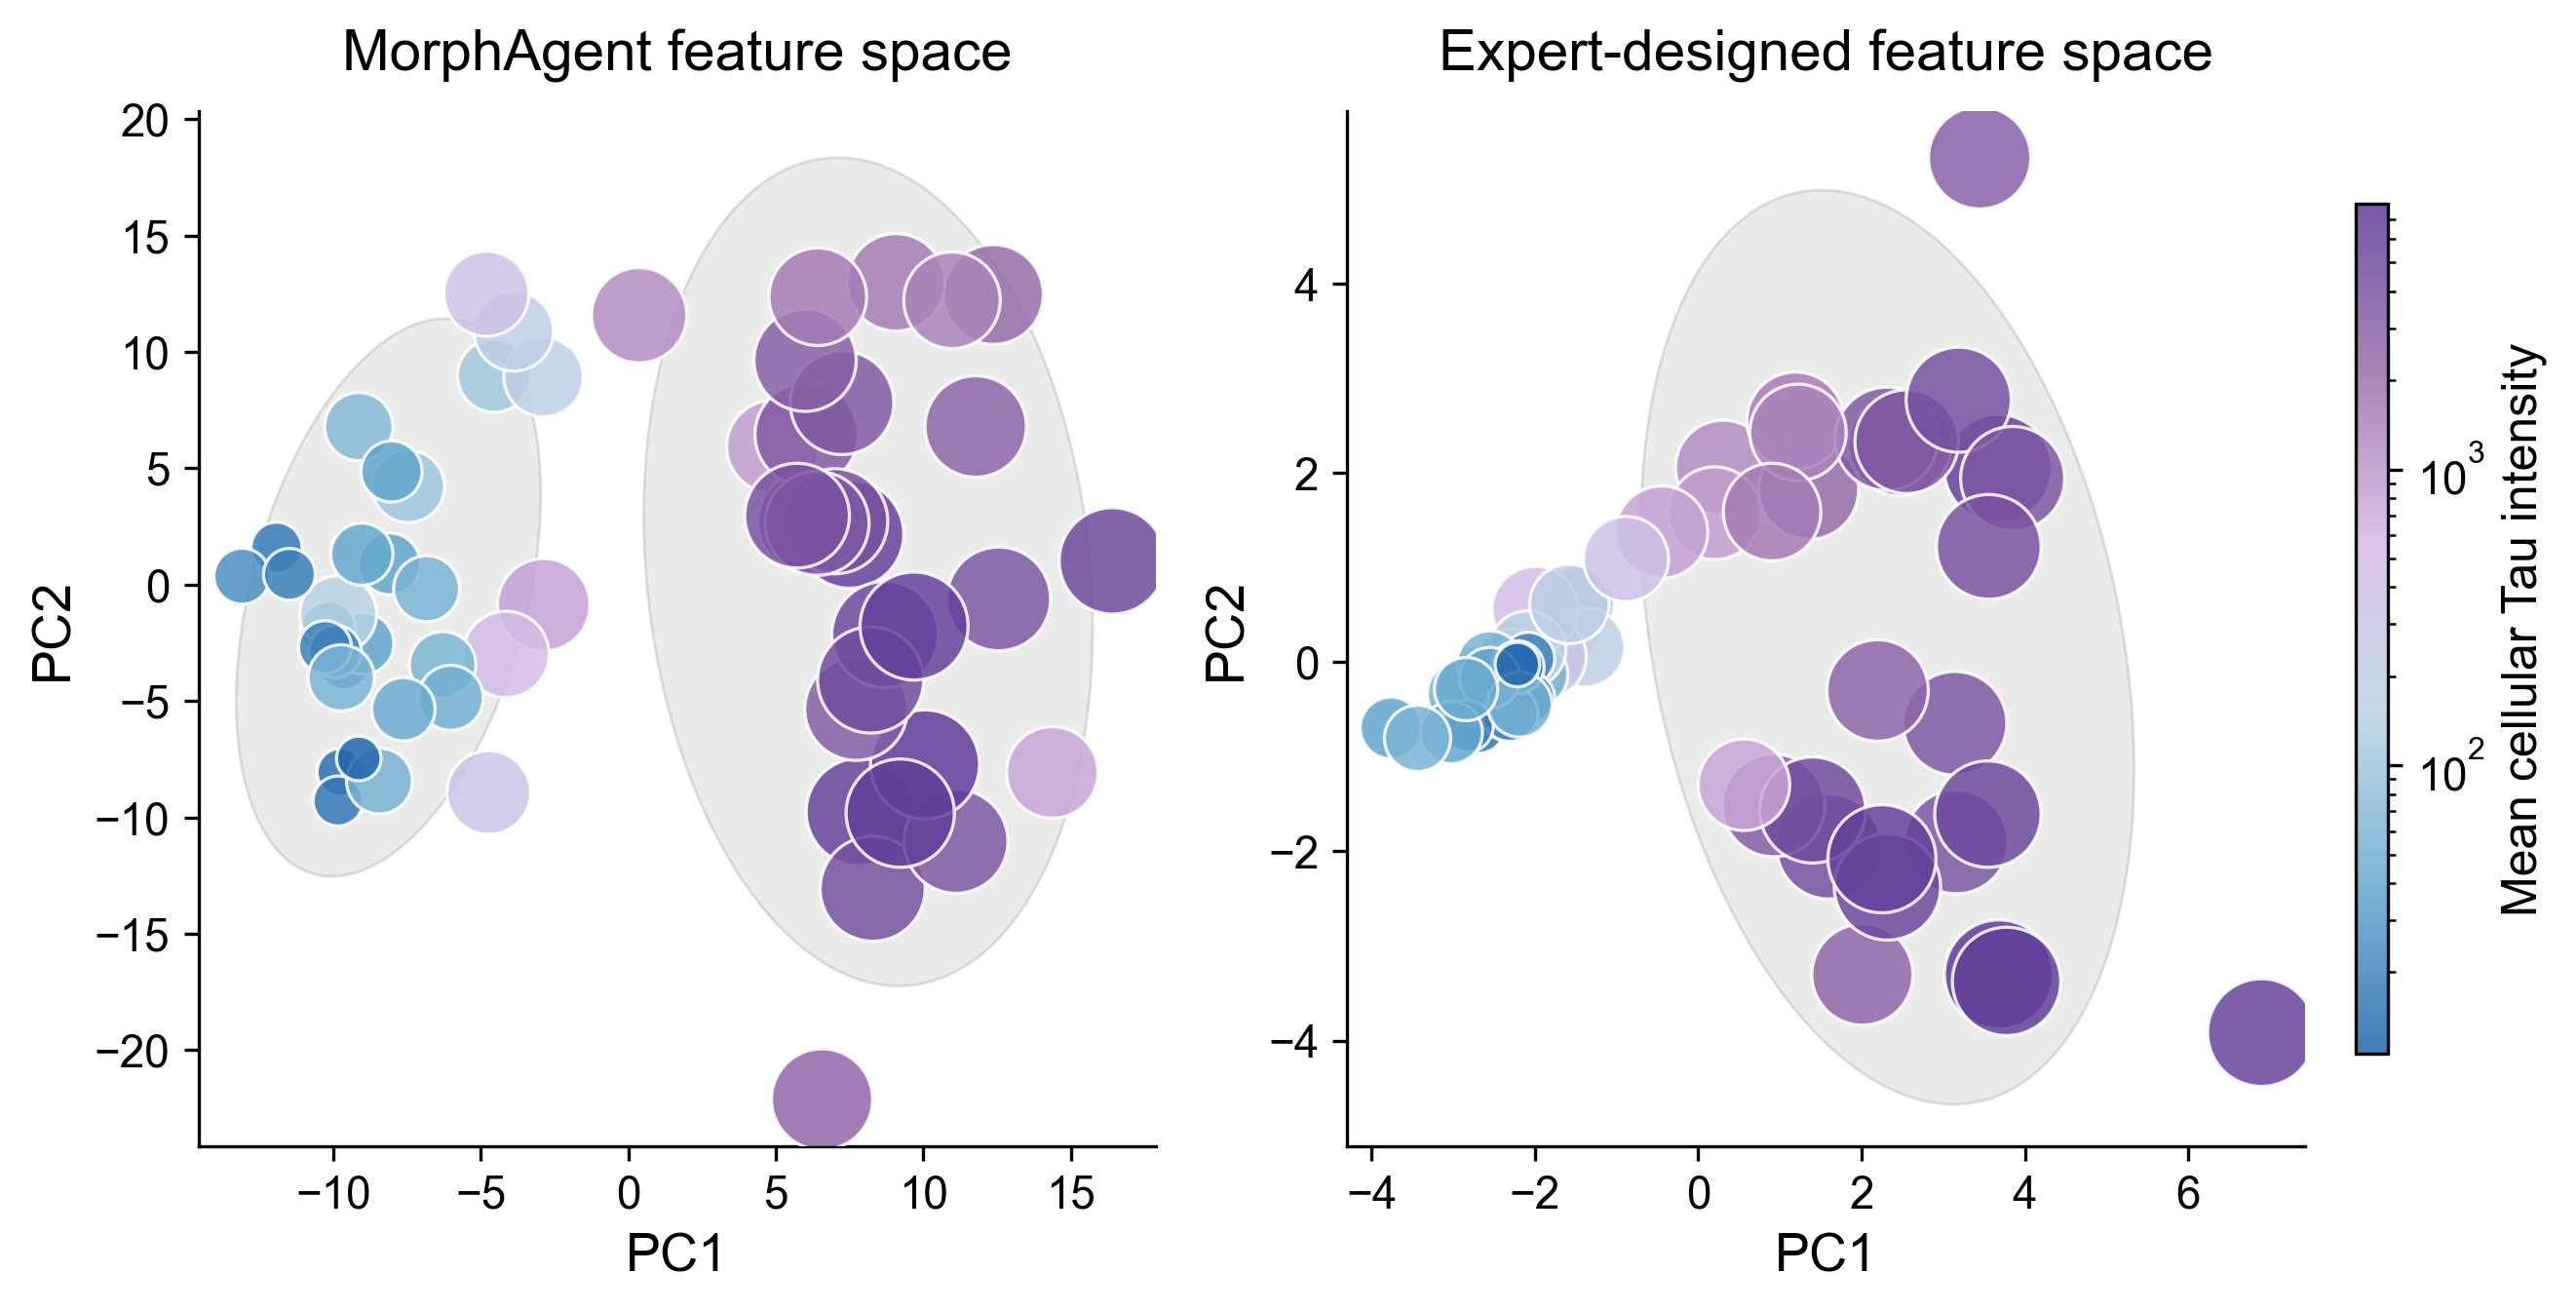

                feature_space  n_features  n_cells  pc1_explained_variance  pc2_explained_variance
     MorphAgent feature space         301       58                0.257398                0.181639
Expert-designed feature space          16       58                0.415197                0.183913


In [73]:
import importlib
importlib.reload(tau_pca)
png_path, pca_summary = tau_pca.plot_feature_space_comparison(cohort_wt)
display(Image(filename=str(png_path)))
print(pca_summary.to_string(index=False))

The grey ellipses are 95% covariance ellipses of the low- and
high-intensity halves of the cohort (median split on Tau intensity),
included as a visual guide to the abundance gradient rather than as a
fitted result.

The quantitative handle on this panel is how variance is distributed. A
16-feature expert panel is close to one dominant axis of Tau abundance, so
it concentrates far more variance in PC1. The MorphAgent space spreads
variance across many more directions — that difference in effective
dimensionality is the point of the comparison.

In [74]:
checks["§2 feature space"] = tau_pca.compare_pca_to_published(pca_summary)
print(checks["§2 feature space"].to_string(index=False))
assert checks["§2 feature space"].filter(like="_match").all().all()
print("\nBoth projections match the published explained variance.")

                feature_space  n_features  pc1_reproduced_pct  pc1_explained_variance_pct  pc1_match  pc2_reproduced_pct  pc2_explained_variance_pct  pc2_match
     MorphAgent feature space         301                25.7                        25.7       True                18.2                        18.2       True
Expert-designed feature space          16                41.5                        41.5       True                18.4                        18.4       True

Both projections match the published explained variance.


---
## 3. WT versus the P301S+S320F double mutant

**Claim under test.** MorphAgent features discriminate genotype better than
the expert panel in both imaging modalities, and the advantage is largest
under super-resolution.

The cohort is an independent mutant dataset in which every cell was imaged
twice — once at super-resolution (SR) and once wide-field (WF). Imaging
modality and genotype are both encoded in the cell identifier, so labels are
derived rather than supplied separately.

In [75]:
tables = tc.load_cohort()
print(tc.cohort_overview(tables).to_string(index=False))

print("\nhow labels are read off an identifier:")
for sid in tables["morphagent"]["sample_id"].head(3):
    print(f"  {sid:<28} modality={tc.modality_from_id(sid):<3} genotype={tc.genotype_from_id(sid)}")

          feature_family modality  n_features  n_cells  WT  S320F  S305I  P301LS320F  P301SandS320F  P301L
              MorphAgent       SR         350      495  69     59    135          55             44     64
              MorphAgent       WF         350      498  69     61    134          55             44     64
expert-designed features       SR          14      495  69     59    135          55             44     64
expert-designed features       WF          14      498  69     61    134          55             44     64

how labels are read off an identifier:
  sr_P301LandS320F_1           modality=SR  genotype=P301LS320F
  sr_P301LandS320F_10          modality=SR  genotype=P301LS320F
  sr_P301LandS320F_11          modality=SR  genotype=P301LS320F


Each panel is a two-dimensional view of the fitted model: the horizontal
axis is the signed distance to the separating hyperplane, so the dashed
decision line sits at zero, and the vertical axis is the leading principal
component of the subspace orthogonal to it.

Saved data/outputs/fig4d_binary_classification.png/.svg/.pdf


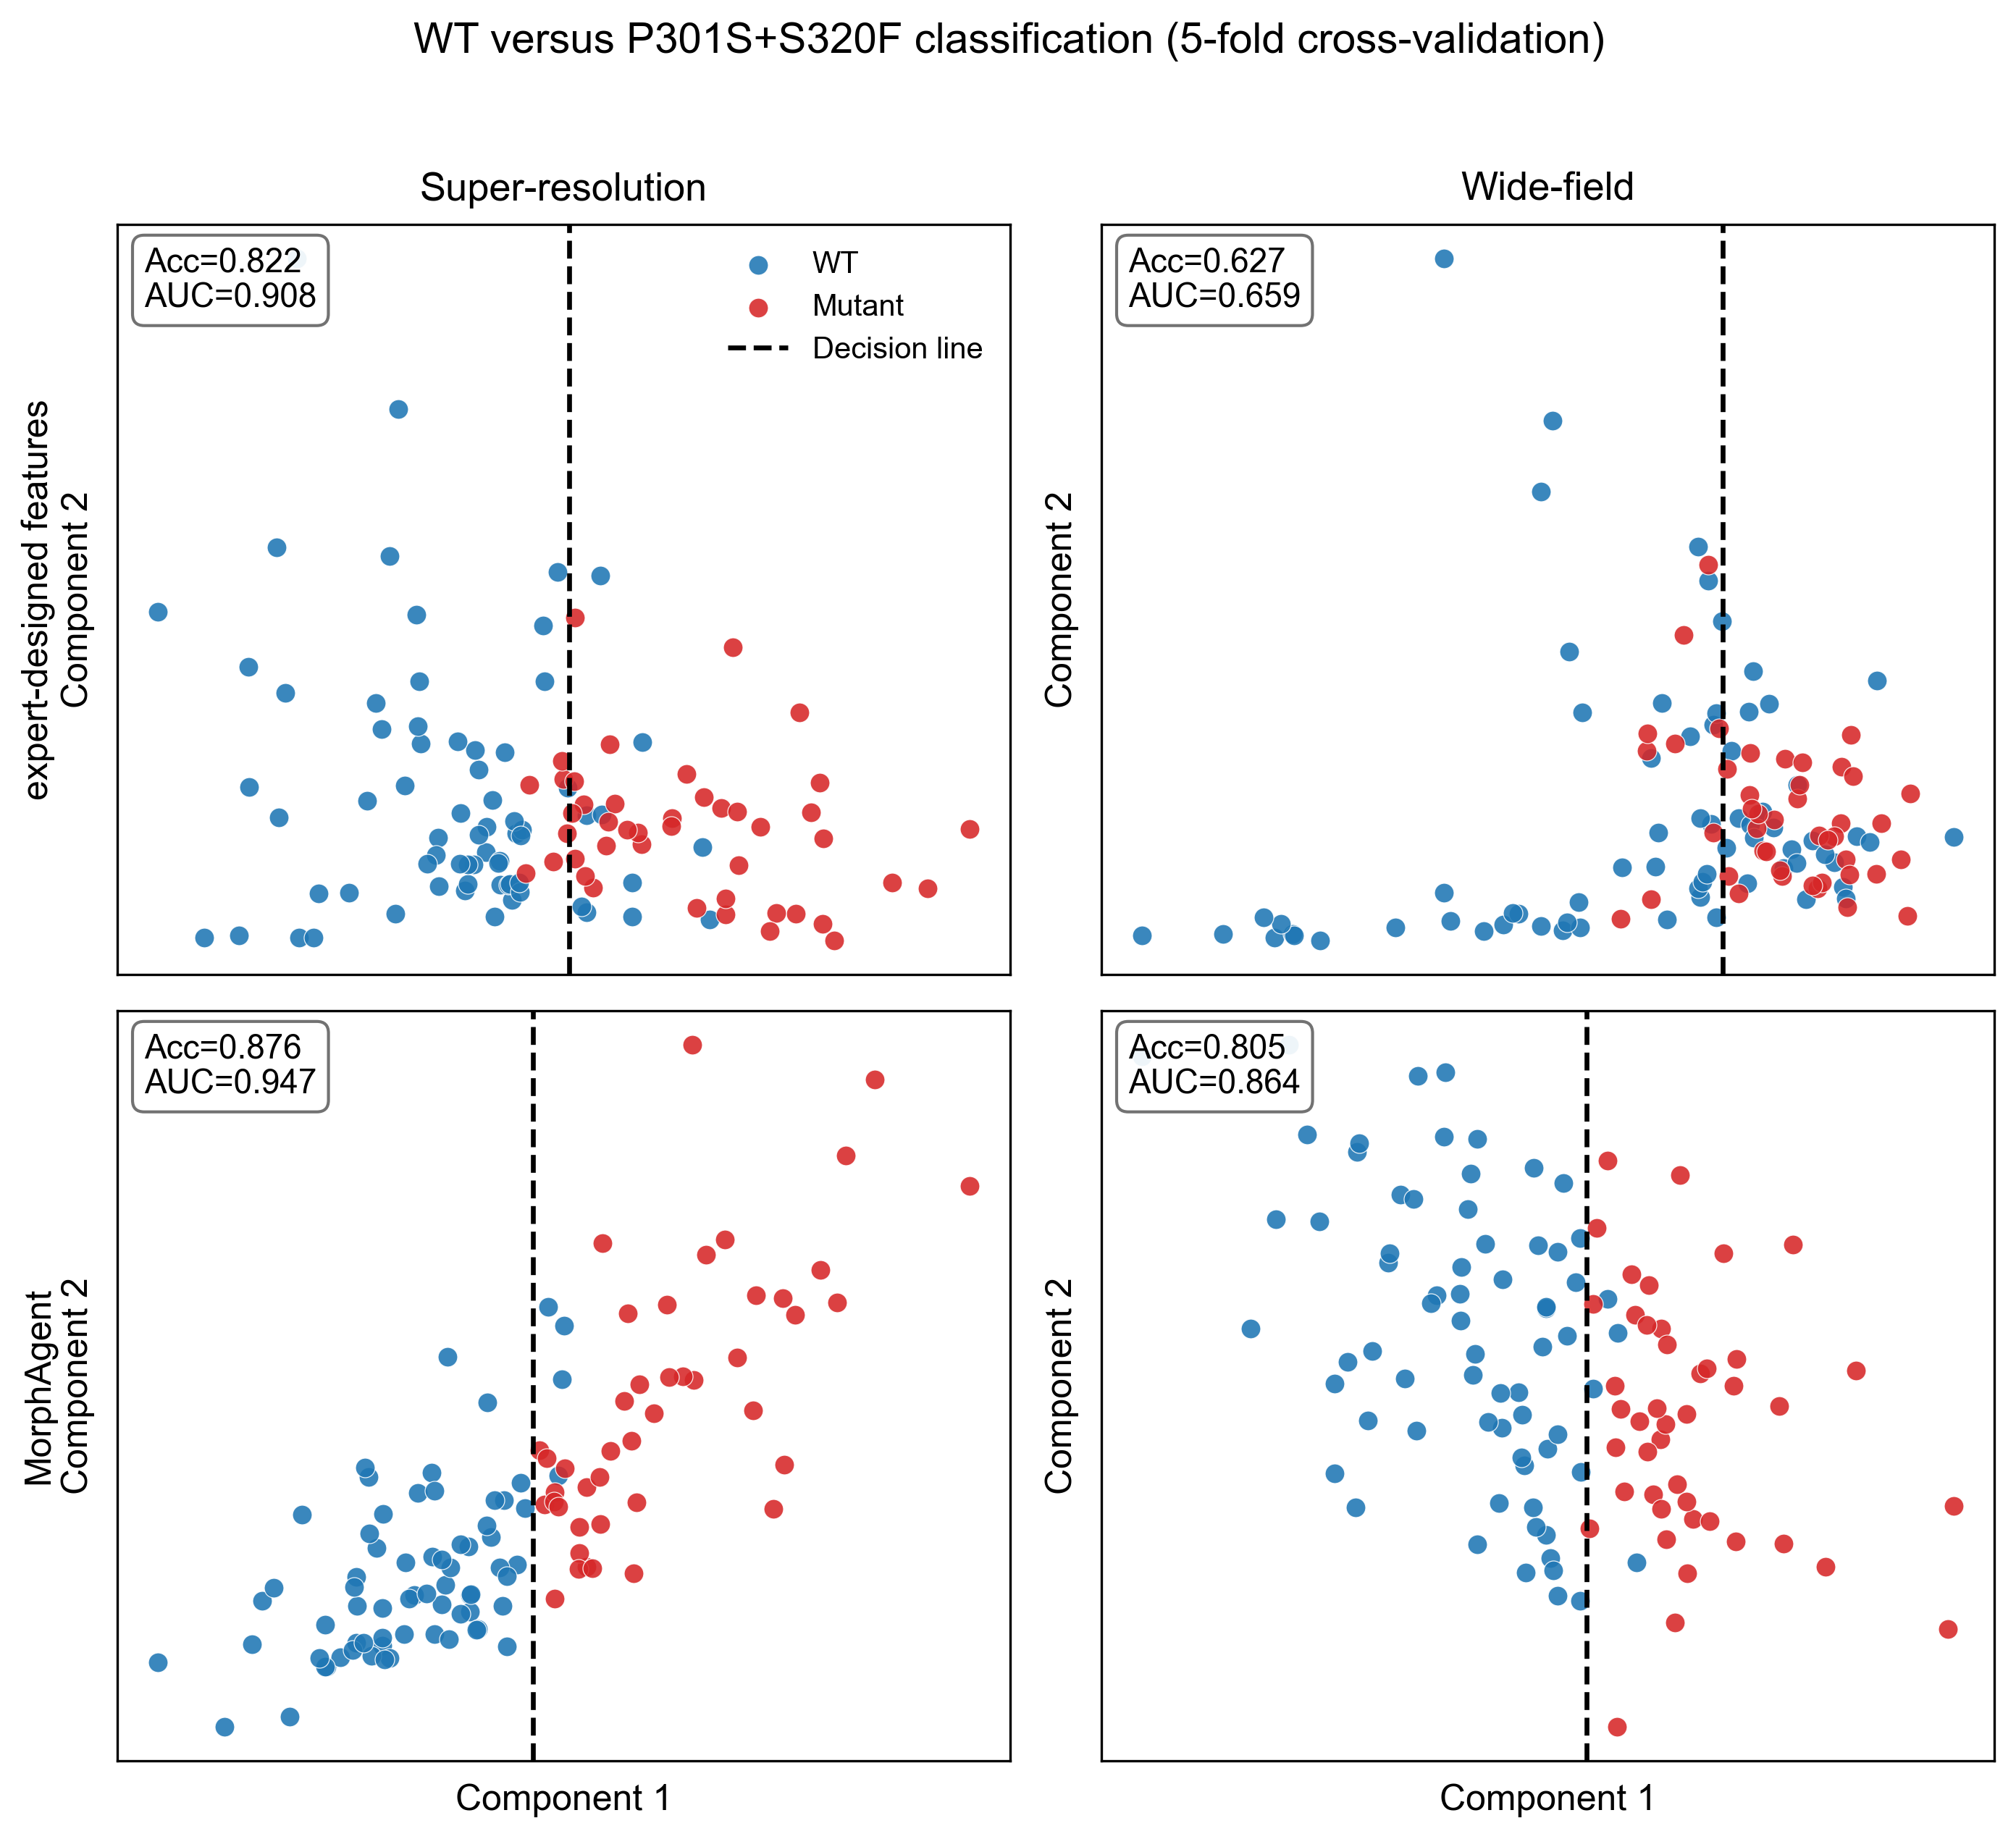

          feature_family modality  n_features_used  n_cells  n_wt  n_mutant  cv_accuracy  cv_roc_auc
expert-designed features       SR               14      113    69        44     0.822134    0.908120
expert-designed features       WF               14      113    69        44     0.626877    0.658501
              MorphAgent       SR               50      113    69        44     0.876285    0.947283
              MorphAgent       WF               50      113    69        44     0.805138    0.863736


In [76]:
binary = tc.run_binary_panels(tables, top_k=tc.TOP_K_MORPHAGENT)
png_path = tc.plot_binary_panels(binary)
display(Image(filename=str(png_path)))
print(binary["metrics"].to_string(index=False))

In [77]:
checks["§3 binary"] = tc.compare(
    binary["metrics"].rename(
        columns={"cv_accuracy": "cv_accuracy_mean", "cv_roc_auc": "cv_roc_auc_mean"}
    ),
    tc.reference_binary_metrics(),
    ["cv_accuracy_mean", "cv_roc_auc_mean"],
)
print(checks["§3 binary"][[
    "feature_family", "modality",
    "cv_accuracy_mean_reproduced", "cv_accuracy_mean_published", "cv_accuracy_mean_match_3dp",
    "cv_roc_auc_mean_reproduced", "cv_roc_auc_mean_published", "cv_roc_auc_mean_match_3dp",
]].to_string(index=False))

assert checks["§3 binary"].filter(like="match_3dp").all().all()
print("\nAll eight values match the manuscript to three decimal places.")

          feature_family modality  cv_accuracy_mean_reproduced  cv_accuracy_mean_published  cv_accuracy_mean_match_3dp  cv_roc_auc_mean_reproduced  cv_roc_auc_mean_published  cv_roc_auc_mean_match_3dp
expert-designed features       SR                     0.822134                    0.822134                        True                    0.908120                   0.908120                       True
expert-designed features       WF                     0.626877                    0.626877                        True                    0.658501                   0.658501                       True
              MorphAgent       SR                     0.876285                    0.876285                        True                    0.947283                   0.947283                       True
              MorphAgent       WF                     0.805138                    0.805138                        True                    0.863736                   0.863736                       

MorphAgent leads in both modalities. The informative contrast is how much
each family loses when it drops from super-resolution to wide-field: the
expert panel falls by roughly 0.20 accuracy, MorphAgent by about 0.07. Much
of the expert panel's discriminative signal therefore lives in nanoscale
Tau organisation that wide-field blurs away, whereas MorphAgent keeps usable
signal at both scales.

---
## 4. Six-class Tau genotype discrimination

**Claim under test.** The expanded feature space improves genotype
resolution beyond a two-class contrast.

This task spans WT and five Tau mutants and uses every available feature in
each family — no selection step. Alongside accuracy we report the macro
one-vs-rest false-positive rate, averaged over classes, where lower is
better.

In [78]:
sixclass = tc.run_sixclass(tables)
print(sixclass["summary"].to_string(index=False))

          feature_family family_key modality  n_features  n_cells  accuracy  macro_fpr
expert-designed features     expert       SR          14      426  0.377866   0.124209
expert-designed features     expert       WF          14      427  0.278687   0.143772
              MorphAgent morphagent       SR         350      426  0.544651   0.095121
              MorphAgent morphagent       WF         350      427  0.492011   0.103242


Significance comes from a paired stratified bootstrap over the out-of-fold
predictions. Every cell is predicted exactly once, in its held-out fold;
cells are then resampled within genotype and both arms are scored on the
same resampled cells, which is possible because each cell was imaged in both
modalities. Comparisons are reported in the table below the figure rather
than annotated on the bars.

Saved data/outputs/fig4i_sixclass_genotype.png/.svg/.pdf


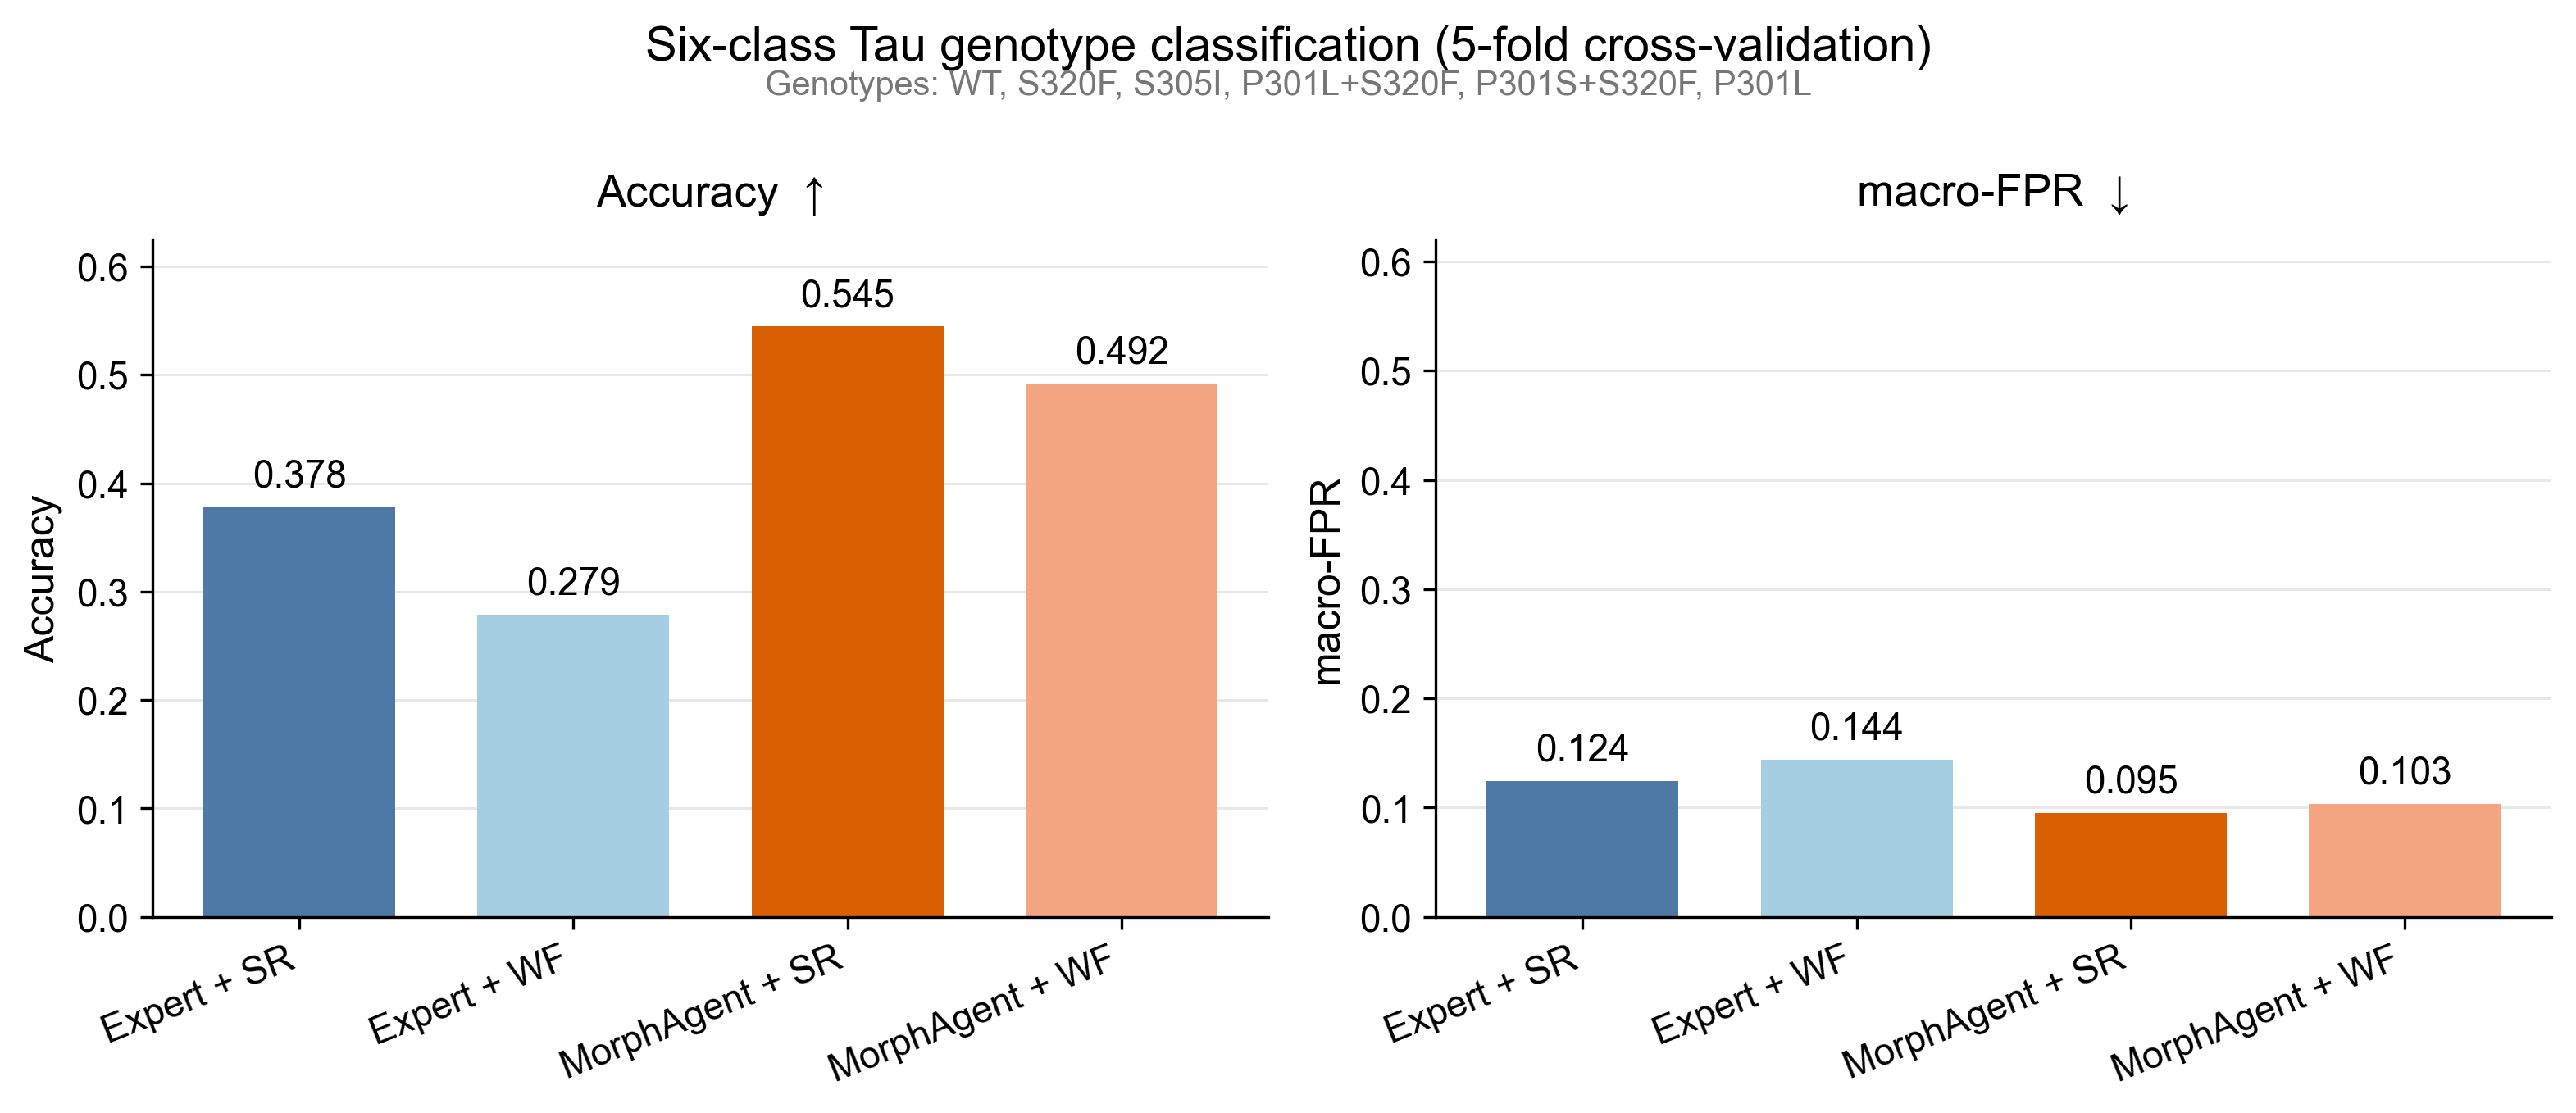

   metric         group_a         group_b  n_paired_cells  mean_difference  p_bootstrap stars
 Accuracy     Expert + SR MorphAgent + SR             426        -0.166398       0.0005   ***
 Accuracy     Expert + WF MorphAgent + SR             425        -0.268432       0.0005   ***
 Accuracy MorphAgent + SR MorphAgent + WF             425         0.051793       0.0820    ns
macro-FPR     Expert + SR MorphAgent + SR             426         0.029060       0.0005   ***
macro-FPR     Expert + WF MorphAgent + SR             425         0.049182       0.0005   ***
macro-FPR MorphAgent + SR MorphAgent + WF             425        -0.008052       0.1880    ns


In [79]:
import importlib
importlib.reload(tc)
png_path, sixclass_significance = tc.plot_sixclass(sixclass, n_bootstrap=2000)
display(Image(filename=str(png_path)))
print(sixclass_significance.to_string(index=False))

In [80]:
checks["§4 six-class"] = tc.compare(
    sixclass["summary"], tc.reference_sixclass_metrics(), ["accuracy", "macro_fpr"]
)
print(checks["§4 six-class"][[
    "feature_family", "modality",
    "accuracy_reproduced", "accuracy_published", "accuracy_match_3dp",
    "macro_fpr_reproduced", "macro_fpr_published", "macro_fpr_match_3dp",
]].to_string(index=False))

assert checks["§4 six-class"].filter(like="match_3dp").all().all()
print("\nAll eight values match the manuscript to three decimal places.")

          feature_family modality  accuracy_reproduced  accuracy_published  accuracy_match_3dp  macro_fpr_reproduced  macro_fpr_published  macro_fpr_match_3dp
expert-designed features       SR             0.377866            0.377866                True              0.124209             0.124209                 True
expert-designed features       WF             0.278687            0.278687                True              0.143772             0.143772                 True
              MorphAgent       SR             0.544651            0.544651                True              0.095121             0.095121                 True
              MorphAgent       WF             0.492011            0.492011                True              0.103242             0.103242                 True

All eight values match the manuscript to three decimal places.


MorphAgent gains about 0.17 accuracy over the expert panel at
super-resolution while cutting the macro false-positive rate, and both
gaps are significant. The super-resolution-versus-wide-field difference
within MorphAgent is not significant under this test, which the table
reports rather than omits.

Summary metrics cannot say *which* genotypes get confused, so the pooled
cross-validated confusion matrices are worth a look.

In [81]:
for family in ("expert", "morphagent"):
    print(f"\n{tc.FAMILY_LABEL[family]} — super-resolution (rows = true, columns = predicted)")
    print(tc.confusion_table(sixclass, family, "SR").to_string())


expert-designed features — super-resolution (rows = true, columns = predicted)
             WT  S320F  S305I  P301L+S320F  P301S+S320F  P301L
WT           17     11     12           11            3     15
S320F        10     19      9            4            2     15
S305I        31     34     27           19           11     13
P301L+S320F   3      4      6           29           10      3
P301S+S320F   1      5      4            6           20      8
P301L         4      5      0            1            5     49

MorphAgent — super-resolution (rows = true, columns = predicted)
             WT  S320F  S305I  P301L+S320F  P301S+S320F  P301L
WT           34      5     21            8            1      0
S320F         6     25     20            0            0      8
S305I        19     28     67           11            5      5
P301L+S320F  14      1      9           26            4      1
P301S+S320F   3      1      3            5           29      3
P301L         3      6      3      

---
## 5. Predicting gene expression from Tau morphology

**Claim under test.** Tau morphology carries transcriptomic information that
Tau abundance alone does not.

Morphology and transcriptome were measured on the same cells. Three
predictor sets are compared gene by gene, with Tau intensity as the
single-feature baseline that abundance-only explanations would predict is
sufficient.

| Arm | Predictors |
|---|---|
| MorphAgent | the 400 descriptors from `source/feature_lists` |
| Expert | the handcrafted reference panel |
| Tau intensity | the single mean-intensity readout |

Set `MAX_GENES` to an integer for a fast pass; leave it at `None` to score
the full transcriptome, which is what the published comparison requires.

In [82]:
# None runs the full transcriptome (~7 min on 24 workers); an integer caps the gene count.
MAX_GENES = None
N_JOBS = 24

cohort_pred = tp.load_cohort(max_genes=MAX_GENES)
splits = tp.load_splits(10)

print(f"cells : {len(cohort_pred['sample_ids'])}")
print(f"genes : {len(cohort_pred['genes'])}")
for arm in tp.ARMS:
    print(f"  {arm:<14} {cohort_pred['X'][arm].shape[1]:>3} predictors")
sizes = {k: len(splits[0][k]) for k in ("train_idx", "val_idx", "test_idx")}
print(f"\nresamples    : {len(splits)}")
print(f"per resample : {sizes}")

cells : 58
genes : 19810
  MorphAgent     400 predictors
  Expert          16 predictors
  Tau intensity    1 predictors

resamples    : 10
per resample : {'train_idx': 40, 'val_idx': 9, 'test_idx': 9}


### 5.1 Evaluation protocol

Each arm is evaluated with the procedure used for it in the manuscript, and
those procedures are not identical — `tau_prediction.ARM_PROTOCOL` records
which applies to which arm.

**MorphAgent.** For each gene and resample, the 400 predictors are ranked by
absolute Pearson correlation with the target using train and validation
cells only. A support-vector regressor is fitted on the top *k* predictors
for *k* in {1, 2, 4, 8, 16, 32, 64} and scored on the held-out test cells.
The two best-scoring *k* are averaged into an ensemble, whose mean test
correlation is the gene's score.

**Expert and Tau intensity.** All predictors of the arm are used with no
ranking step. Ten regressor configurations are drawn from a fixed grid and
chosen by Spearman correlation on the inner validation cells, then refitted
on train and validation and scored on test.

In [83]:
for arm in tp.ARMS:
    print(f"  {arm:<14} {tp.ARM_PROTOCOL[arm]}")
print(f"\nk values searched by the MorphAgent arm : {tp.K_VALUES}")
print(f"ensemble size                            : {tp.ENSEMBLE_TOP_N}")
print(f"configuration grid size                  : {len(tp.svr_grid())}")
print(f"configurations tried per gene/resample   : {tp.N_PARAM_TRIALS}")

  MorphAgent     screen_topk_ensemble
  Expert         all_features_param_search
  Tau intensity  all_features_param_search

k values searched by the MorphAgent arm : [1, 2, 4, 8, 16, 32, 64]
ensemble size                            : 2
configuration grid size                  : 128
configurations tried per gene/resample   : 10


### 5.2 Score every gene

This is the expensive cell. Per-gene scores are written to `data/outputs/`
so the cells below can be re-run without refitting anything.

In [86]:
per_gene = tp.score_all_arms(cohort_pred, splits, n_jobs=N_JOBS)

for arm, df in per_gene.items():
    df.to_csv(tp.OUTPUT_DIR / f"fig5a_per_gene_{arm.lower().replace(' ', '_')}.csv", index=False)
    print(f"{arm:<14} {len(df):>6} genes, mean r = {np.nanmean(df.mean_pearson):+.4f}")

[MorphAgent] genes=19810 predictors=400 k=[1, 2, 4, 8, 16, 32, 64] repeats=10 n_jobs=24
[MorphAgent] done in 138.9s, mean=0.1178
[Expert] genes=19810 predictors=16 (no ranking) config trials=10 repeats=10 n_jobs=24
[Expert] done in 289.1s, mean=0.0057
[Tau intensity] genes=19810 predictors=1 (no ranking) config trials=10 repeats=10 n_jobs=24
[Tau intensity] done in 208.8s, mean=-0.0024
MorphAgent      19810 genes, mean r = +0.1178
Expert          19810 genes, mean r = +0.0057
Tau intensity   19810 genes, mean r = -0.0024


### 5.3 Build the panel

Each arm is ranked by its own scores, so the top-5,000 and top-1,000 panels
use a different gene set per arm rather than a shared one. A gene whose
correlation is undefined counts as zero, which keeps all three panels
averaging over the same gene universe.

Saved data/outputs/fig5a_gene_expression_prediction.png/.svg/.pdf


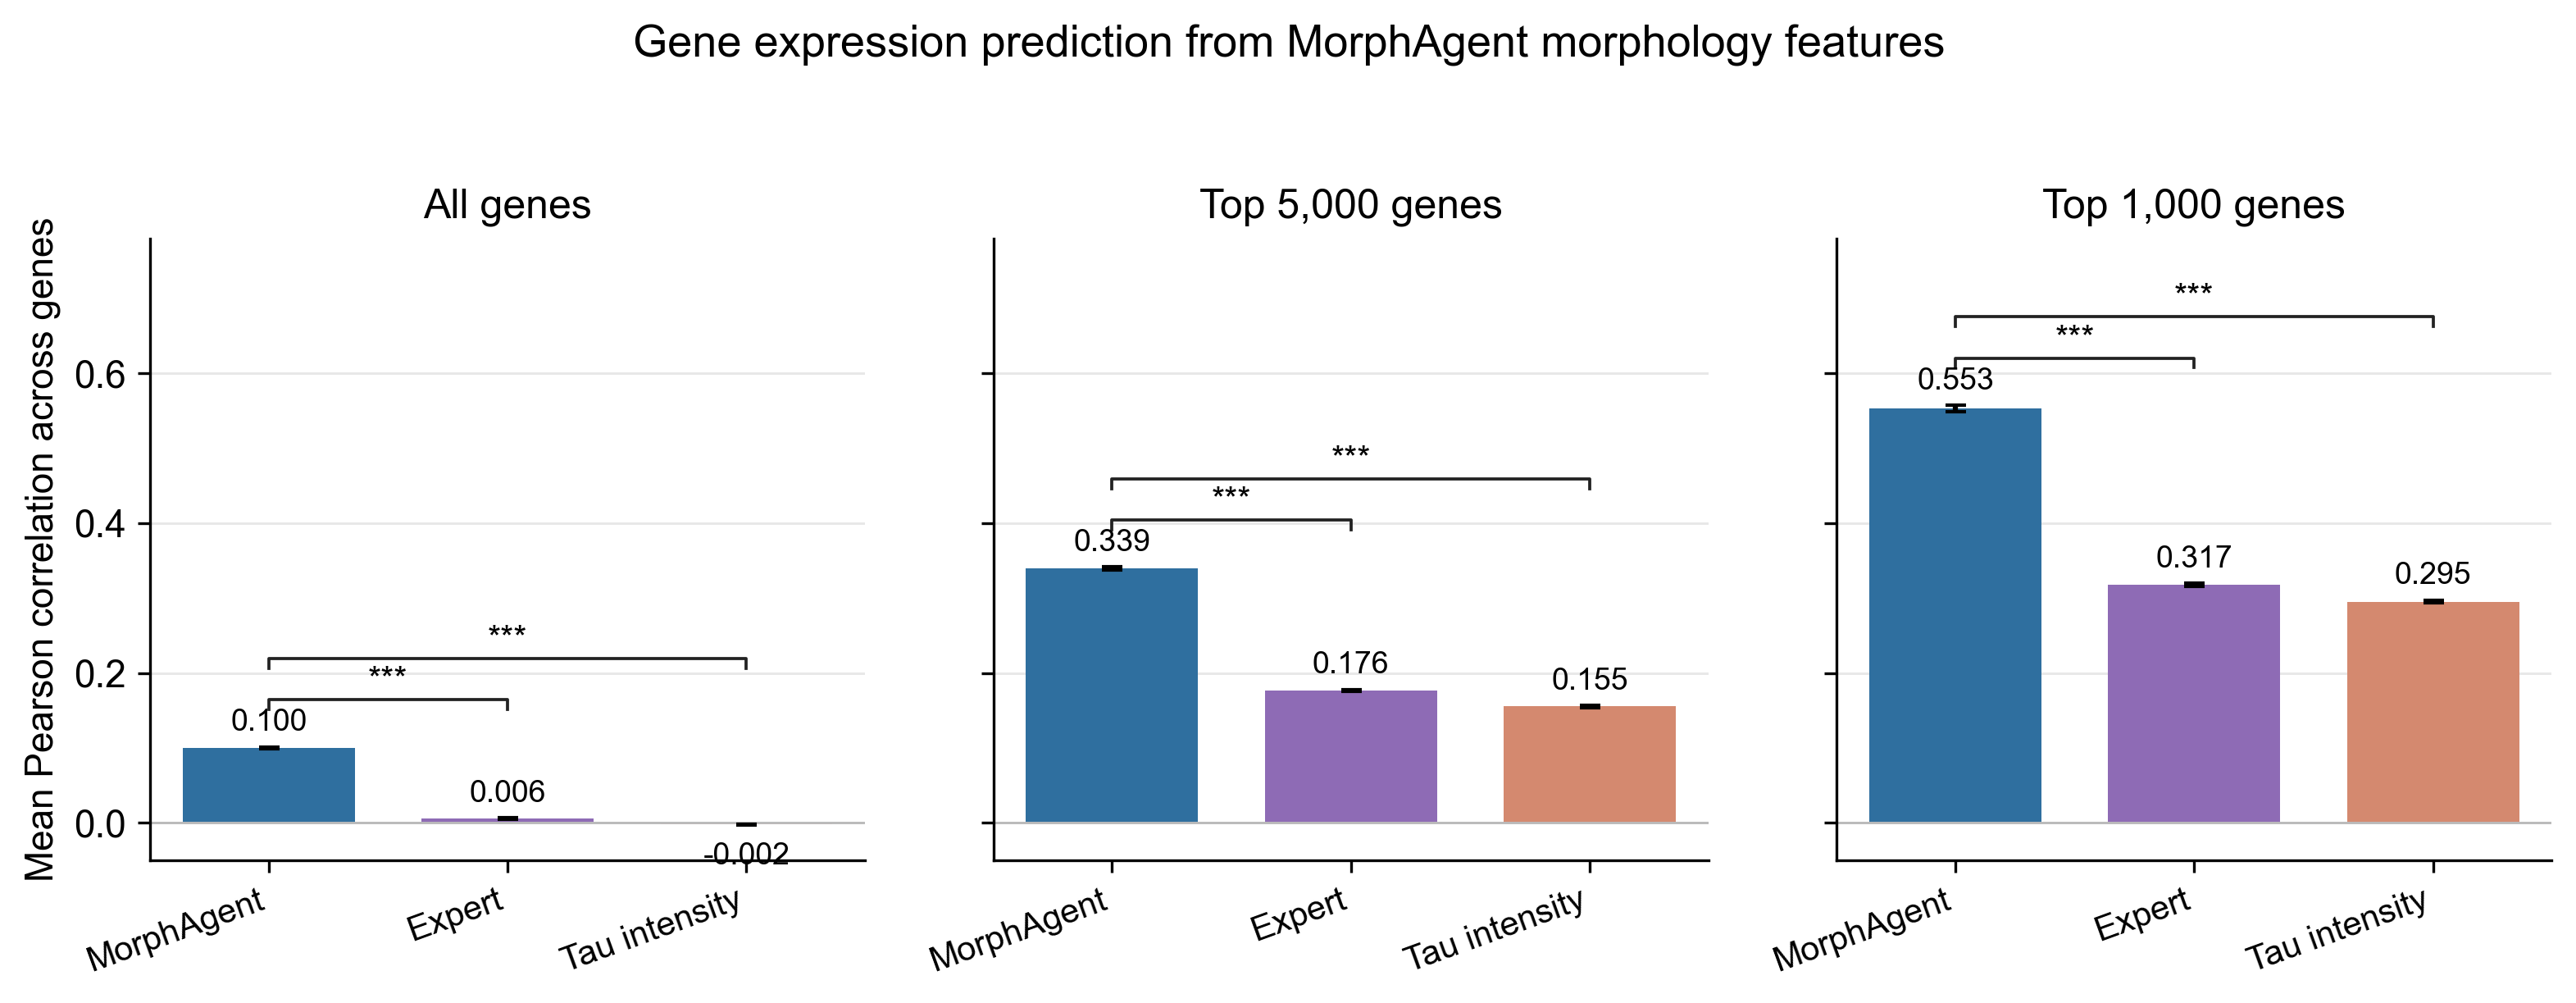

         panel   feature_set  n_genes  mean_pearson      sem  median_pearson
     All genes    MorphAgent    19810      0.099905 0.001260        0.064353
     All genes        Expert    19810      0.005707 0.000937        0.000000
     All genes Tau intensity    19810     -0.002413 0.000887        0.000000
Top-5000 genes    MorphAgent     5000      0.339357 0.001891        0.299719
Top-5000 genes        Expert     5000      0.176338 0.001229        0.153424
Top-5000 genes Tau intensity     5000      0.155184 0.001212        0.131137
Top-1000 genes    MorphAgent     1000      0.553014 0.004249        0.501503
Top-1000 genes        Expert     1000      0.317351 0.002044        0.301281
Top-1000 genes Tau intensity     1000      0.295213 0.002122        0.279750


In [87]:
summary_pred, raw_pred = tp.summarize(per_gene)
summary_pred.to_csv(tp.OUTPUT_DIR / "fig5a_summary.csv", index=False)

png_path, pred_significance = tp.plot_prediction_panel(summary_pred, raw_pred)
display(Image(filename=str(png_path)))
print(summary_pred.to_string(index=False))

---
## 6. Top-level morphology–GO correspondence

**Claim under test.** Image-defined Tau morphology modules and independently
defined GO gene programs converge on the same genes.

MorphAgent features were grouped into 11 morphology-defined biological
processes. Each class is assigned the union of genes correlated with its
member features (`|ρ| ≥ 0.4`). Each enriched GO term contributes its member
genes; nine mitochondrial terms are merged into one column, and two redundant
terms are dropped, giving an 11 × 11 matrix. The cell value is the
**shared-gene count** — how many genes are jointly implicated by a
morphology class and a GO program.


In [ ]:
morph_classes = th.load_morphology_classes()
go_terms = th.load_go_terms()

print(f"morphology classes : {len(morph_classes)}")
print(f"GO terms (display) : {len(go_terms)}")
print()
print(morph_classes[["bp_id", "bp_display", "n_features", "n_genes"]].to_string(index=False))
print()
print(go_terms[["go_display_order", "go_short", "n_genes"]].to_string(index=False))


In [ ]:
top = th.top_level_overlap(morph_classes, go_terms)
top.to_csv(paths.OUTPUT_DIR / "fig5d_bp_go_overlap_long.csv", index=False)

print("boxed correspondences in the published panel:")
print(th.highlight_summary(top).to_string(index=False))

png_path = th.plot_top_level_heatmap(top)


In [ ]:
png_path = th.plot_top_level_heatmap(top)


In [ ]:
checks["§6 top-level heatmap"] = th.compare_top_level(top)
n_ok = int(checks["§6 top-level heatmap"]["match"].sum())
n_tot = len(checks["§6 top-level heatmap"])
print(f"{n_ok} of {n_tot} cells match the published shared-gene counts.")
assert n_ok == n_tot


The RNA-centric block (mRNA processing, ribonucleoprotein complex
biogenesis, spliceosomal complex, ribosome biogenesis) is the densest
overlap. Two correspondences are boxed for the next section: Tau
mislocalization × mRNA processing / spliceosomal complex, and
Tau-positive object maturation × ribonucleoprotein complex biogenesis /
lysosomal membrane.


---
## 7. Middle-level architecture–GRN correspondence

**Claim under test.** The boxed top-level pairs resolve into specific
subcellular architectures and GRN regulatory modules.

Each morphology class is split by structure-size into subcellular
architectures; each architecture's gene set is the union of genes
correlated with its features. On the gene side, GRN modules are the
transcription factor plus its top-decile targets inside the GO term. The
two panels expand:

| Morphology class | GO term | GRNs |
|---|---|---|
| Tau-positive object maturation (BP06) | ribonucleoprotein complex biogenesis | 8 |
| Tau mislocalization (BP01) | spliceosomal complex | 3 |


In [ ]:
feat2genes = th.load_feature_genes()
print(f"features with correlated genes: {len(feat2genes)}")

for job in th.MIDDLE_JOBS:
    sas = th.architecture_gene_sets(job["bp_id"], feat2genes)
    grns = th.load_grns(job["go_term"])
    print(f"\n{job['bp_display']}  ({job['bp_id']}, {len(sas)} architectures)")
    print(pd.DataFrame(sas)[["sa_local_id", "architecture", "n_features", "n_genes"]].to_string(index=False))
    print(f"\nGRNs in {job['go_term']}:")
    print(grns[["GRN_id", "TF", "targets", "n_genes"]].to_string(index=False))


In [ ]:
middle = {}
for job in th.MIDDLE_JOBS:
    df = th.middle_level_overlap(job, feat2genes)
    df.to_csv(paths.OUTPUT_DIR / f"fig5e_{job['bp_id'].lower()}_overlap_long.csv", index=False)
    middle[job["bp_id"]] = df
    nz = df[df["shared_gene_count"] > 0]
    print(f"\n{job['bp_display']} × {job['go_term']}  ({len(nz)} non-zero cells)")
    print(nz[[
        "architecture_display", "GRN_id", "GRN_TF", "shared_gene_count", "shared_genes"
    ]].to_string(index=False))

png_path = th.plot_middle_level_panel(middle)


In [ ]:
png_path = th.plot_middle_level_panel(middle)


On the left, overlap is size-graded: small puncta share RPS15, cytoplasmic
architectures pick up RPP25 / EIF3K / TSR2, and the boundary architecture
shares two genes (EIF3K, SNRPC) with the SNRPB2 module. On the right, Tau
mislocalization maps onto the spliceosomal circuit at the perinuclear ring
(SNRPC, RNPC3), the nuclear boundary (RALY), and whole-cell geometry (SUGP1).


---
## 8. All reproduced numbers in one place


In [ ]:
lines = []
for label, frame in checks.items():
    cols = [c for c in frame.columns if c.endswith(("_match", "_match_3dp", "agrees")) or c == "match"]
    total = int(frame[cols].size)
    passed = int(frame[cols].to_numpy().sum())
    lines.append({"section": label, "values_checked": total, "agreeing": passed})

audit = pd.DataFrame(lines)
print(audit.to_string(index=False))
print(f"\n{audit.agreeing.sum()} of {audit.values_checked.sum()} reported values reproduced.")
print(f"\nFigures and tables written to: {paths.rel(paths.OUTPUT_DIR)}")


Taken together: MorphAgent's designed features span a much wider Tau
phenotypic space than a curated expert panel, convert that width into better
genotype discrimination in both a two-class and a six-class setting, recover
transcriptomic structure that Tau abundance alone misses, and organise that
shared component as a matched morphology–gene hierarchy — biological
processes versus GO functions at the top, subcellular architectures versus
GRN modules in the middle.
